# 🌀 Experimento CHFT v2 — Orquestador Modular

Este notebook importa y ejecuta el experimento **CHFT (Complex Holographic Field Theory)** utilizando la estructura modular importada directamente desde la carpeta sincronizada en **Google Drive**.

In [16]:
# 1. Montar Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ Google Drive montado exitosamente.")
except ImportError:
    print("⚠️ No se pudo importar google.colab. Ejecutando en entorno local.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive montado exitosamente.


In [17]:
# 2. Instalar dependencias en Google Colab
import sys
if 'google.colab' in sys.modules:
    !pip install -q datasets tiktoken

In [18]:
# 3. Configurar rutas y recargar dinámicamente los módulos (Compatible con Python 3.12)
import os
import sys
import torch
import importlib

found_path = None

# Intentar rutas comunes primero para velocidad
potential_paths = [
    '/content/drive/MyDrive/colab/src',
    '/content/drive/MyDrive/01-CHFT/colab/src',
    './colab/src',
    './src'
]

for p in potential_paths:
    if os.path.exists(os.path.join(p, 'model.py')):
        found_path = p
        break

# Si no está en las rutas comunes, buscar dinámicamente en Google Drive
if not found_path and os.path.exists('/content/drive/MyDrive'):
    print("🔍 Buscando carpeta de código 'src' en Google Drive (puede demorar unos segundos)...")
    for root, dirs, files in os.walk('/content/drive/MyDrive'):
        if 'src' in dirs and os.path.exists(os.path.join(root, 'src', 'model.py')):
            found_path = os.path.join(root, 'src')
            break

if found_path:
    found_path = os.path.abspath(found_path)
    if found_path not in sys.path:
        sys.path.insert(0, found_path)
    print(f"✅ Código fuente detectado en: {found_path}")
else:
    print("❌ ERROR: No se pudo localizar la carpeta 'src' con el código de Python.")
    print("\n--- CÓMO CORREGIR ESTO (Limitación de Google Drive/Colab) ---")
    print("Colab solo tiene acceso directo a 'Mi Unidad' (My Drive), no a la sección de 'Computadoras'.")
    print("Sigue estos sencillos pasos para que funcione:")
    print("1. Entra a drive.google.com en tu navegador.")
    print("2. Ve a la sección 'Computadoras' -> abre la carpeta de tu computadora y busca la carpeta 'colab'.")
    print("3. Haz clic derecho sobre la carpeta 'colab' (o 'src') y selecciona 'Organizar' > 'Agregar acceso directo'.")
    print("4. Elige 'Mi Unidad' (My Drive) como el destino y haz clic en Agregar.")
    print("5. ¡Listo! Vuelve a ejecutar esta celda y Colab podrá encontrar tus archivos automáticamente.")

# Importar y recargar forzosamente para evitar la caché de Colab (Compatible con Python 3.12)
try:
    import model
    import train
    import evaluate
    import generate
    import save

    # Recarga manual usando importlib (evita usar el antiguo 'imp' de autoreload que fallaba en python 3.12)
    importlib.reload(model)
    importlib.reload(train)
    importlib.reload(evaluate)
    importlib.reload(generate)
    importlib.reload(save)

    from model import FHRRPhasorEmbedding, ModernHopfieldMemory
    from train import prepare_dataset, run_training_loop
    from evaluate import evaluate_model, plot_and_save_results
    from generate import generate_text_topk, calculate_diversity
    from save import save_model_and_results
    print("✅ Módulos CHFT importados y recargados con éxito.")
except ModuleNotFoundError as e:
    print(f"❌ Error al importar módulos: {e}")

✅ Código fuente detectado en: /content/drive/MyDrive/colab/src
✅ Módulos CHFT importados y recargados con éxito.


In [19]:
# 4. Configurar Parámetros
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DIMENSION     = 4096     # Dimensión de los fasores complejos
CONTEXT_LEN   = 8        # Longitud de contexto (ventana)
EPOCHS        = 10       # Más épocas para Colab GPU T4
LEARNING_RATE = 0.01
BATCH_SIZE    = 1024     # Batch size optimizado para GPU
NUM_STORIES   = 1000     # Cantidad de historias TinyStories
TOPK          = 5        # Parámetro K para sampling de texto
VAL_SPLIT     = 0.1      # 10% para validación

print(f"✅ Dispositivo: {DEVICE}")
print(f"✅ Parámetros: Dim={DIMENSION}, Contexto={CONTEXT_LEN}, Batch={BATCH_SIZE}, Historias={NUM_STORIES}")

✅ Dispositivo: cuda
✅ Parámetros: Dim=4096, Contexto=8, Batch=1024, Historias=1000


In [20]:
# 5. Cargar y Preparar Datos
train_ctx, train_tgt, val_ctx, val_tgt, token_to_idx, idx_to_token, vocab, vocab_size, tokenizer, targets_tensor = prepare_dataset(
    num_stories=NUM_STORIES,
    context_len=CONTEXT_LEN,
    val_split=VAL_SPLIT,
    device=DEVICE
)

      Cargando TinyStories...
      Tokenizando y extrayendo vocabulario...
      Vocabulario: 5,424 tokens únicos
      Train: 194,096 muestras | Val: 21,566 muestras


In [21]:
# 6. Inicializar Componentes de CHFT
codebook = FHRRPhasorEmbedding(vocab_size, DIMENSION).to(DEVICE)
hopfield_mem = ModernHopfieldMemory(beta=16.0)
hopfield_mem.update_keys(codebook)

total_params = sum(p.numel() for p in codebook.parameters())
print(f"✅ Parámetros del Codebook: {total_params:,} ({total_params * 4 / 1e6:.2f} MB en float32)")

✅ Parámetros del Codebook: 22,216,704 (88.87 MB en float32)


In [ ]:
# 7. Entrenar el Modelo
loss_history, val_loss_history, elapsed = run_training_loop(
    codebook=codebook,
    hopfield_mem=hopfield_mem,
    train_ctx=train_ctx,
    train_tgt=train_tgt,
    val_ctx=val_ctx,
    val_tgt=val_tgt,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    device=DEVICE
)


Iniciando Entrenamiento CHFT...
  Epoch 01/10 | Train Loss: 7.0109 | Val Loss: 5.9880
  Epoch 02/10 | Train Loss: 5.6883 | Val Loss: 5.6983
  Epoch 03/10 | Train Loss: 5.4326 | Val Loss: 5.5953
  Epoch 04/10 | Train Loss: 5.2740 | Val Loss: 5.5358
  Epoch 05/10 | Train Loss: 5.1604 | Val Loss: 5.4975
  Epoch 06/10 | Train Loss: 5.0769 | Val Loss: 5.4742
  Epoch 07/10 | Train Loss: 5.0181 | Val Loss: 5.4607
  Epoch 08/10 | Train Loss: 4.9785 | Val Loss: 5.4532
  Epoch 09/10 | Train Loss: 4.9541 | Val Loss: 5.4498
  Epoch 10/10 | Train Loss: 4.9419 | Val Loss: 5.4490

✅ Entrenamiento completado en 249.9s (4.2 min)


In [ ]:
# 8. Evaluar Métricas
accuracy, perplexity, base_acc = evaluate_model(
    codebook=codebook,
    val_ctx=val_ctx,
    val_tgt=val_tgt,
    batch_size=BATCH_SIZE,
    vocab_size=vocab_size,
    targets_tensor=targets_tensor,
    val_split=VAL_SPLIT
)


Calculando métricas de benchmark...
  Accuracy@1  : 8.29%   (tokens exactos predichos)
  Perplexity  : 236.87  (menor = mejor; azar ≈ 5,424)

  [Baseline freq] Accuracy@1: 6.90%  (siempre predice token más frecuente)
  [CHFT v2]       Accuracy@1: 8.29%  (+1.38pp vs baseline)


In [ ]:
# 9. Generar Texto de Prueba
import math
test_prompts = [
    ("Once upon a time",       20),
    ("A little girl saw",      20),
    ("The cat went to",        20),
    ("There was a small dog",  20),
    ("The sun was shining",    20),
]

for prompt, length in test_prompts:
    result = generate_text_topk(
        prompt=prompt,
        codebook=codebook,
        hopfield_mem=hopfield_mem,
        tokenizer=tokenizer,
        token_to_idx=token_to_idx,
        idx_to_token=idx_to_token,
        context_len=CONTEXT_LEN,
        device=DEVICE,
        max_new=length,
        k=TOPK,
        temperature=0.8
)
    print(f"  📝 Prompt : '{prompt}'")
    print(f"     Output : {result}\n")

# Calcular e imprimir Diversidad
unique_ratio = calculate_diversity(
    prompts=test_prompts,
    codebook=codebook,
    hopfield_mem=hopfield_mem,
    tokenizer=tokenizer,
    token_to_idx=token_to_idx,
    idx_to_token=idx_to_token,
    context_len=CONTEXT_LEN,
    device=DEVICE,
    k=TOPK,
    temperature=0.8
)

  📝 Prompt : 'Once upon a time'
     Output : Once upon a time, there little was girl very who. had 

 inThe so to.

, have " and the

  📝 Prompt : 'A little girl saw'
     Output : A little girl saw something. They were scared in was a big and He. wanted They are it to, go a

  📝 Prompt : 'The cat went to'
     Output : The cat went to get. They saw it said, but was to The go so on and a the " said.

  📝 Prompt : 'There was a small dog'
     Output : There was a small dog. They loved were to go and on, ". I They," to make it but a She

  📝 Prompt : 'The sun was shining'
     Output : The sun was shining to be in her and saw. It was a so big with " and the, â but he

── Métrica de Diversidad ──
  Tokens totales generados: 265
  Tokens únicos           : 90
  Diversity score         : 34.0%  (100% = sin repetición)



Graficando resultados...


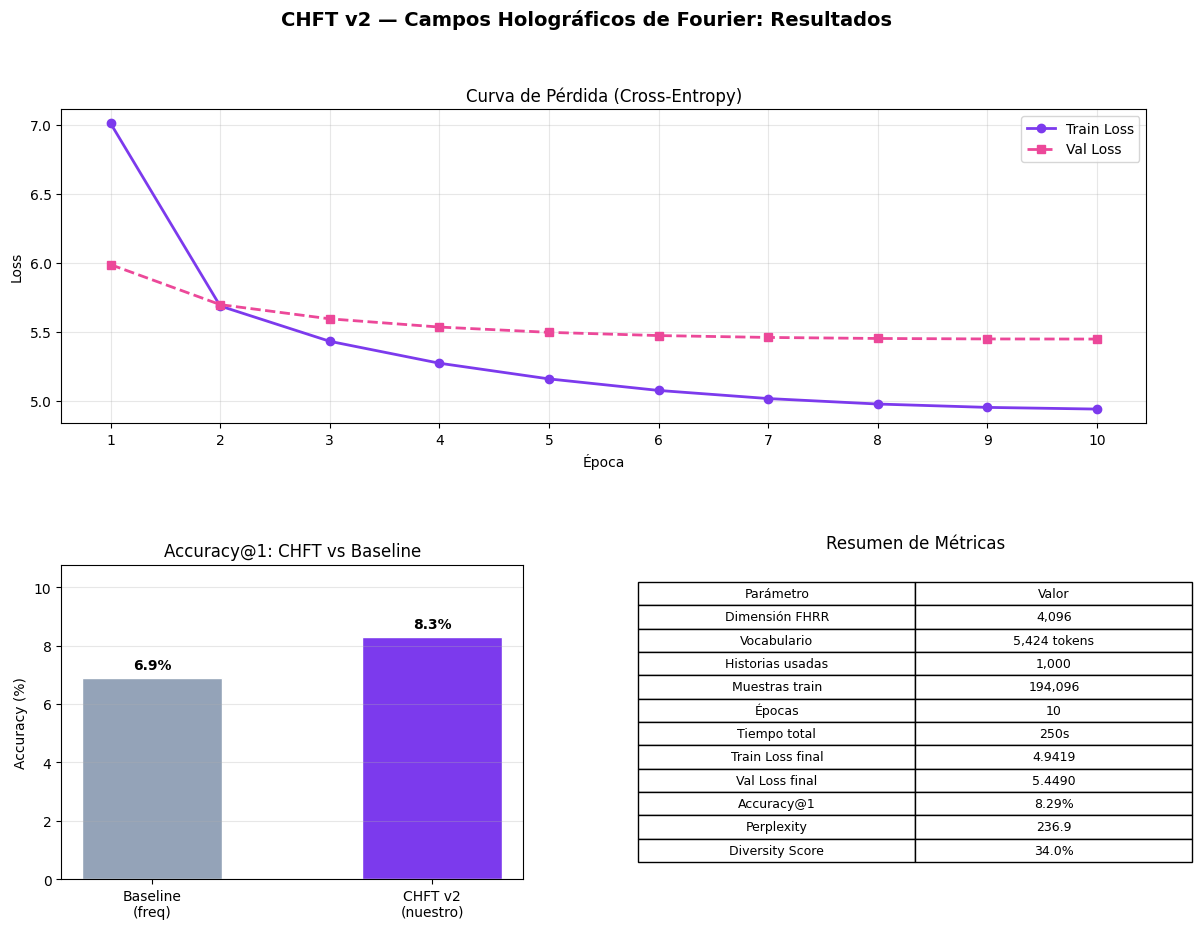

✅ Figura mostrada en pantalla.


In [ ]:
# 10. Graficar y Mostrar Métricas
plot_and_save_results(
    epochs=EPOCHS,
    loss_history=loss_history,
    val_loss_history=val_loss_history,
    base_acc=base_acc,
    accuracy=accuracy,
    dimension=DIMENSION,
    vocab_size=vocab_size,
    num_stories=NUM_STORIES,
    num_train=len(train_ctx),
    elapsed=elapsed,
    unique_ratio=unique_ratio,
    perplexity=perplexity,
    filename="chft_benchmark_results.png"
)

In [ ]:
# 11. Guardar Todo en Drive (Omitido temporalmente)
# drive_dest_dir = '/content/drive/MyDrive/colabStore/01-CHFT'
#
# metrics_dict = {
#     "accuracy_pct":     accuracy,
#     "perplexity":       perplexity,
#     "baseline_acc_pct": base_acc,
#     "diversity_pct":    unique_ratio,
#     "train_loss_final": loss_history[-1],
#     "val_loss_final":   val_loss_history[-1],
#     "epochs":           EPOCHS,
#     "training_secs":    elapsed,
# }
#
# save_model_and_results(
#     drive_dest_dir=drive_dest_dir,
#     codebook=codebook,
#     token_to_idx=token_to_idx,
#     idx_to_token=idx_to_token,
#     vocab=vocab,
#     vocab_size=vocab_size,
#     dimension=DIMENSION,
#     context_len=CONTEXT_LEN,
#     metrics=metrics_dict,
#     local_chart_path="chft_benchmark_results.png"
# )